# Fresh ML Transaction Profiles

Fresh ten-step measurements: direct SmartSim diagnostic `2492044`, PhyDLL diagnostic `2478296`, and AIx diagnostics `2524580` (natural) / `2525508` (barrier).


In [1]:
from pathlib import Path
import re
import shutil
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

CUBE_DUMP = shutil.which('cube_dump') or '/hpcwork/ro092286/smartsim/CPP-ML-Interface/tmp/opencode/scorep-8.4-papi72-install/bin/cube_dump'
PROFILE_ROOT = Path('/hpcwork/ro092286/smartsim/mini_app/scorep_runs')
if not PROFILE_ROOT.exists():
    PROFILE_ROOT = Path('/rwthfs/rz/cluster/hpcwork/ro092286/smartsim/mini_app/scorep_runs')

PROFILE_RUNS = {
    'AIX': 'AIX_DIAG_NATURAL_2524580_rank_0',
    'SmartSim': 'SMARTSIM_SCOREP_METRICS_2492044_rank_0',
    'PhyDLL': 'PHYDLL_SCOREP_DIAG_2478296_rank_0',
}
LIBRARY_REGION = {
    'AIX': 'aix_library_static_step',
    'SmartSim': 'smartsim_library_static_step',
    'PhyDLL': 'phydll_library_static_step',
}
print(PROFILE_ROOT)


/hpcwork/ro092286/smartsim/mini_app/scorep_runs


In [2]:
LINE = re.compile(r'^(.+?)\(id=(\d+)\)\s+([0-9.eE+-]+)$')
METRIC = re.compile(r'^Print out the data of the metric (\S+)$')
THREAD = re.compile(r'Master thread \(id=(\d+),')

def profile_path(provider):
    return PROFILE_ROOT / PROFILE_RUNS[provider] / 'profile.cubex'

def thread_ids(profile):
    result = subprocess.run([CUBE_DUMP, '-w', 'systemtree', str(profile)], capture_output=True, text=True, check=True)
    return [int(value) for value in THREAD.findall(result.stdout)]

def rank_metrics(profile, thread_id, provider):
    def dump(metrics, calltree_mode):
        result = subprocess.run([CUBE_DUMP, '-m', metrics, '-c', 'all', '-t', str(thread_id), '-z', calltree_mode, '-s', 'human', '-o', '-', str(profile)], capture_output=True, text=True, check=True)
        metric = None
        rows = []
        for line in result.stdout.splitlines():
            marker = METRIC.match(line.strip())
            if marker:
                metric = marker.group(1)
                continue
            match = LINE.match(line.strip())
            if match and metric in set(metrics.split(',')):
                rows.append({'metric': metric, 'region': match.group(1).strip(), 'region_id': int(match.group(2)), 'value': float(match.group(3))})
        return rows
    # Stage time must be call-tree inclusive, while visits remain exclusive.
    rows = dump('time', 'incl') + dump('min_time,max_time,visits', 'excl')
    provider_metrics = {
        'AIX': 'aix_input_bytes,aix_output_bytes,aix_device_batches',
        'PhyDLL': 'bytes_sent_logical,bytes_sent_actual,bytes_recv_logical,bytes_recv_actual',
        'SmartSim': 'smartsim_input_bytes,smartsim_output_bytes,smartsim_put_requests,smartsim_run_requests,smartsim_unpack_requests',
    }
    if provider in provider_metrics:
        rows += dump(provider_metrics[provider], 'excl')
    metric = None
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    return frame.pivot(index=['region_id', 'region'], columns='metric', values='value').reset_index().fillna(0)

def load_profile(provider):
    profile = profile_path(provider)
    if not profile.exists():
        raise FileNotFoundError(profile)
    frames = []
    for thread_id in thread_ids(profile):
        frame = rank_metrics(profile, thread_id, provider)
        if not frame.empty:
            frame['provider'] = provider
            frame['thread_id'] = thread_id
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)

def calltree_paths(profile):
    result = subprocess.run([CUBE_DUMP, '-w', 'calltree', str(profile)], capture_output=True, text=True, check=True)
    paths = []
    stack = []
    for line in result.stdout.splitlines():
        if '|-' not in line or '( id=' not in line:
            continue
        marker = line.index('|-')
        node = line[marker + 2:]
        name, rest = node.split('[', 1)
        id_match = re.search(r'\( id=(\d+)', rest)
        if not id_match:
            continue
        # CUBE omits vertical connectors for last siblings, so indentation
        # width is irregular. The nearest preceding shallower node is the parent.
        while stack and stack[-1][0] >= marker:
            stack.pop()
        stack.append((marker, name.strip()))
        paths.append({'name': name.strip(), 'region_id': int(id_match.group(1)), 'path': tuple(item[1] for item in stack)})
    return paths

CALLTREES = {provider: calltree_paths(profile_path(provider)) for provider in PROFILE_RUNS}
SOLVER_RANKS = {'AIX': set(range(24)), 'SmartSim': set(range(24)), 'PhyDLL': set(range(24))}
CONTROLLER_RANK = {'AIX': 24}
SERVICE_RANK = {'PhyDLL': 24}

profiles = {provider: load_profile(provider) for provider in PROFILE_RUNS}
{provider: frame.thread_id.nunique() for provider, frame in profiles.items()}


{'AIX': 25, 'SmartSim': 24, 'PhyDLL': 25}

In [3]:
def latest_region(frame, name):
    return frame[frame.region.eq(name)].sort_values('region_id').drop_duplicates('thread_id', keep='last')

def steady_region(frame, provider, name):
    paths = CALLTREES[provider]
    steady_nodes = [item for item in paths if item['name'] == 'solver_step_ml_steady']
    if len(steady_nodes) != 1:
        raise AssertionError(f'{provider}: expected one steady call-tree node, found {steady_nodes}')
    prefix = steady_nodes[0]['path']
    ids = {item['region_id'] for item in paths if item['name'] == name and item['path'][:len(prefix)] == prefix}
    return frame[frame.region_id.isin(ids)]

def per_rank_step_time(provider, name, role='solver'):
    frame = profiles[provider]
    roots = steady_region(frame, provider, 'solver_step_ml_steady')
    if role == 'solver':
        threads = SOLVER_RANKS[provider]
    elif role == 'controller':
        threads = {CONTROLLER_RANK[provider]}
    else:
        threads = {SERVICE_RANK[provider]}
    roots = roots[roots.thread_id.isin(threads) & roots.visits.gt(0)].set_index('thread_id')
    values = steady_region(frame, provider, name).set_index('thread_id')
    joined = roots[['visits']].join(values[['time', 'min_time', 'max_time', 'visits']], rsuffix='_stage', how='left')
    if joined.empty:
        return pd.Series(dtype=float)
    # Use inclusive stage time divided by the parent steady-step visits.
    return (joined.time / joined.visits).reindex(sorted(threads)).dropna()

stages = []
for provider, library_region in LIBRARY_REGION.items():
    definitions = [
        ('Solver input preparation', 'solver_ml_prepare_input', False),
        ('Application preprocessing', 'app_prepare_input', False),
        ('Library static step', library_region, False),
        ('Application postprocessing', 'app_finalize_output', False),
        ('Solver output copy', 'solver_ml_output_copy', False),
        ('Solver output application', 'solver_ml_apply_output', False),
    ]
    for stage, region, is_cont in definitions:
        values = per_rank_step_time(provider, region)
        stages.append({'provider': provider, 'stage': stage, 'mean_s': values.mean(), 'min_s': values.min(), 'max_s': values.max()})
    root_values = per_rank_step_time(provider, 'solver_step_ml_steady')
    stages.append({'provider': provider, 'stage': 'ML transaction wall time', 'mean_s': root_values.mean(), 'min_s': root_values.min(), 'max_s': root_values.max()})

transaction = pd.DataFrame(stages)
display(transaction.round(6))

aix_controller = pd.DataFrame([
    {'stage': name, 'mean_s': values.mean(), 'min_s': values.min(), 'max_s': values.max()}
    for name in ['gatherInputData', 'inferenceDevice', 'scatterOutputData']
    for values in [per_rank_step_time('AIX', name, role='controller')]
])
print('AIX controller rank 24:')
display(aix_controller.round(6))


,provider,stage,mean_s,min_s,max_s
0,AIX,Solver input preparation,0.054166,0.036794,0.070959
1,AIX,Application preprocessing,0.000002,0.000001,0.000004
2,AIX,Library static step,1.629819,1.586688,1.657980
3,AIX,Application postprocessing,0.000003,0.000002,0.000004
4,AIX,Solver output copy,0.002153,0.001386,0.002823
5,AIX,Solver output application,0.004490,0.003831,0.005089
6,AIX,ML transaction wall time,1.752851,1.752155,1.753442
7,SmartSim,Solver input preparation,NaN,NaN,NaN
8,SmartSim,Application preprocessing,NaN,NaN,NaN
9,SmartSim,Library static step,1.423026,1.358328,1.447005


AIX controller rank 24:


,stage,mean_s,min_s,max_s
0,gatherInputData,0.944168,0.944168,0.944168
1,inferenceDevice,0.464212,0.464212,0.464212
2,scatterOutputData,0.042416,0.042416,0.042416


In [4]:
def per_rank_metric(provider, region, metric, role='solver'):
    frame = profiles[provider]
    roots = steady_region(frame, provider, 'solver_step_ml_steady')
    if role == 'solver':
        threads = SOLVER_RANKS[provider]
    elif role == 'controller':
        threads = {CONTROLLER_RANK[provider]}
    else:
        threads = set(frame.thread_id.unique())
    roots = roots[roots.thread_id.isin(threads) & roots.visits.gt(0)].set_index('thread_id')
    values = steady_region(frame, provider, region).set_index('thread_id')
    if metric not in values:
        return pd.Series(dtype=float)
    return (roots[['visits']].join(values[[metric]], how='left')[metric] / roots.visits).dropna()

aix_payload = []
for metric, label in [('aix_input_bytes', 'Input payload'), ('aix_output_bytes', 'Output payload')]:
    values = per_rank_metric('AIX', 'inference', metric, role='all')
    aix_payload.append({'metric': label, 'scope': 'sum of all ranks', 'bytes_per_step': values.sum(), 'MiB_per_step': values.sum() / 2**20})
batches = per_rank_metric('AIX', 'aix_controller_inference', 'aix_device_batches', role='controller')
aix_payload.append({'metric': 'Device batches', 'scope': 'controller rank 24', 'bytes_per_step': batches.mean(), 'MiB_per_step': float('nan')})
aix_payload = pd.DataFrame(aix_payload)
print('AIx logical payload and batching:')
display(aix_payload.round(3))

phydll_payload = []
for metric, label in [('bytes_sent_logical', 'Request logical float'), ('bytes_sent_actual', 'Request fixed-field double'), ('bytes_recv_logical', 'Response logical float'), ('bytes_recv_actual', 'Response fixed-field double')]:
    values = per_rank_metric('PhyDLL', 'phydll_library_static_step', metric)
    phydll_payload.append({'metric': label, 'bytes_per_rank_step': values.mean(), 'MiB_per_rank_step': values.mean() / 2**20, 'bytes_all_solver_ranks_step': values.sum()})
phydll_payload = pd.DataFrame(phydll_payload)
print('PhyDLL payload accounting:')
display(phydll_payload.round(3))

smartsim_payload = []
for metric, label in [('smartsim_input_bytes', 'Input tensor payload'), ('smartsim_output_bytes', 'Output tensor payload')]:
    values = per_rank_metric('SmartSim', 'smartsim_library_static_step', metric)
    smartsim_payload.append({'metric': label, 'per_rank_step': values.mean(), 'MiB_per_rank_step': values.mean() / 2**20, 'all_solver_ranks_step': values.sum()})
for metric, region, label in [('smartsim_put_requests', 'smartsim_put_tensor', 'PUT requests'), ('smartsim_run_requests', 'smartsim_run_model', 'RUN requests'), ('smartsim_unpack_requests', 'smartsim_unpack_tensor', 'UNPACK requests')]:
    values = per_rank_metric('SmartSim', region, metric)
    smartsim_payload.append({'metric': label, 'per_rank_step': values.mean(), 'MiB_per_rank_step': float('nan'), 'all_solver_ranks_step': values.sum()})
smartsim_payload = pd.DataFrame(smartsim_payload)
print('SmartSim tensor payload and API requests:')
display(smartsim_payload.round(3))


AIx logical payload and batching:


,metric,scope,bytes_per_step,MiB_per_step
0,Input payload,sum of all ranks,2.687386e+09,2562.891
1,Output payload,sum of all ranks,1.492992e+08,142.383
2,Device batches,controller rank 24,7.470000e+02,NaN


PhyDLL payload accounting:


,metric,bytes_per_rank_step,MiB_per_rank_step,bytes_all_solver_ranks_step
0,Request logical float,111974400.0,106.787,2.687386e+09
1,Request fixed-field double,223948800.0,213.574,5.374771e+09
2,Response logical float,6220800.0,5.933,1.492992e+08
3,Response fixed-field double,223948800.0,213.574,5.374771e+09


SmartSim tensor payload and API requests:


,metric,per_rank_step,MiB_per_rank_step,all_solver_ranks_step
0,Input tensor payload,111974400.0,106.787,2.687386e+09
1,Output tensor payload,6220800.0,5.933,1.492992e+08
2,PUT requests,32.0,NaN,7.680000e+02
3,RUN requests,32.0,NaN,7.680000e+02
4,UNPACK requests,32.0,NaN,7.680000e+02


## AIx Manual Diagnostics

Set `AIX_DIAGNOSTICS_ENV=1` to emit one CSV row per rank and inference call. Set `AIX_DIAGNOSTIC_BARRIERS_ENV=1` only for the synchronized collective-floor experiment. These files are independent of Score-P and can be generated by native builds.

In [5]:
AIX_DIAGNOSTIC_DIR = Path(__import__('os').environ.get(
    'AIX_DIAGNOSTIC_DIR',
    PROFILE_ROOT / PROFILE_RUNS['AIX'].removesuffix('_rank_0') / 'aix_diagnostics',
))
diagnostic_files = sorted(AIX_DIAGNOSTIC_DIR.glob('aix_rank_*.csv'))
AIX_BARRIER_DIAGNOSTIC_DIR = Path(__import__('os').environ.get(
    'AIX_BARRIER_DIAGNOSTIC_DIR',
    PROFILE_ROOT / 'AIX_DIAG_BARRIERS_2525508' / 'aix_diagnostics',
))
if diagnostic_files:
    aix_manual = pd.concat([pd.read_csv(path) for path in diagnostic_files], ignore_index=True)
    aix_manual_summary = aix_manual.groupby('is_controller')[[
        'gather_arrival_wait_s', 'gather_collective_s', 'device_cpu_s',
        'h2d_gpu_ms', 'forward_gpu_ms', 'd2h_gpu_ms',
        'scatter_arrival_wait_s', 'scatter_collective_s',
    ]].agg(['mean', 'min', 'max'])
    display(aix_manual_summary.round(6))
    barrier_files = sorted(AIX_BARRIER_DIAGNOSTIC_DIR.glob('aix_rank_*.csv'))
    if barrier_files:
        aix_barrier = pd.concat([pd.read_csv(path) for path in barrier_files], ignore_index=True)
        phase_columns = [
            'gather_arrival_wait_s', 'gather_collective_s', 'device_cpu_s',
            'h2d_gpu_ms', 'forward_gpu_ms', 'd2h_gpu_ms',
            'scatter_arrival_wait_s', 'scatter_collective_s',
        ]
        aix_modes = pd.concat([
            aix_manual.assign(mode='natural'),
            aix_barrier.assign(mode='barrier-separated'),
        ]).groupby(['mode', 'is_controller'])[phase_columns].mean()
        display(aix_modes.round(6))
else:
    print(f'No AIx manual diagnostics found in {AIX_DIAGNOSTIC_DIR}')


gather_arrival_wait_s         gather_collective_s            \
                               mean min max                mean       min   
is_controller                                                               
0                               0.0   0   0            0.376968  0.022215   
1                               0.0   0   0            0.981304  0.923606   

                        device_cpu_s                      h2d_gpu_ms  ...  \
                    max         mean       min       max        mean  ...   
is_controller                                                         ...   
0              0.901556     0.000000  0.000000  0.000000    0.000000  ...   
1              1.129844     1.235852  0.443282  4.322414  298.007334  ...   

              forward_gpu_ms  d2h_gpu_ms                        \
                         max        mean       min         max   
is_controller                                                    
0                   0.000000    0.000000   0.00000    0.000000   
1                3498.480084  112.808292  49.50368  363.384146   

              scatter_arrival_wait_s         scatter_collective_s            \
                                mean min max                 mean       min   
is_controller                                                                 
0                                0.0   0   0             1.624858  0.484355   
1                                0.0   0   0             0.044060  0.039507   

                         
                    max  
is_controller            
0              5.214337  
1              0.050639  

[2 rows x 24 columns]

gather_arrival_wait_s  gather_collective_s  \
mode              is_controller                                               
barrier-separated 0                           0.013674             0.391961   
                  1                           0.242598             0.752454   
natural           0                           0.000000             0.376968   
                  1                           0.000000             0.981304   

                                 device_cpu_s  h2d_gpu_ms  forward_gpu_ms  \
mode              is_controller                                             
barrier-separated 0                  0.000000    0.000000        0.000000   
                  1                  1.115524  292.713939      614.370372   
natural           0                  0.000000    0.000000        0.000000   
                  1                  1.235852  298.007334      785.722941   

                                 d2h_gpu_ms  scatter_arrival_wait_s  \
mode              is_controller                                       
barrier-separated 0                0.000000                1.476537   
                  1              127.027941                0.000224   
natural           0                0.000000                0.000000   
                  1              112.808292                0.000000   

                                 scatter_collective_s  
mode              is_controller                        
barrier-separated 0                          0.026365  
                  1                          0.048310  
natural           0                          1.624858  
                  1                          0.044060

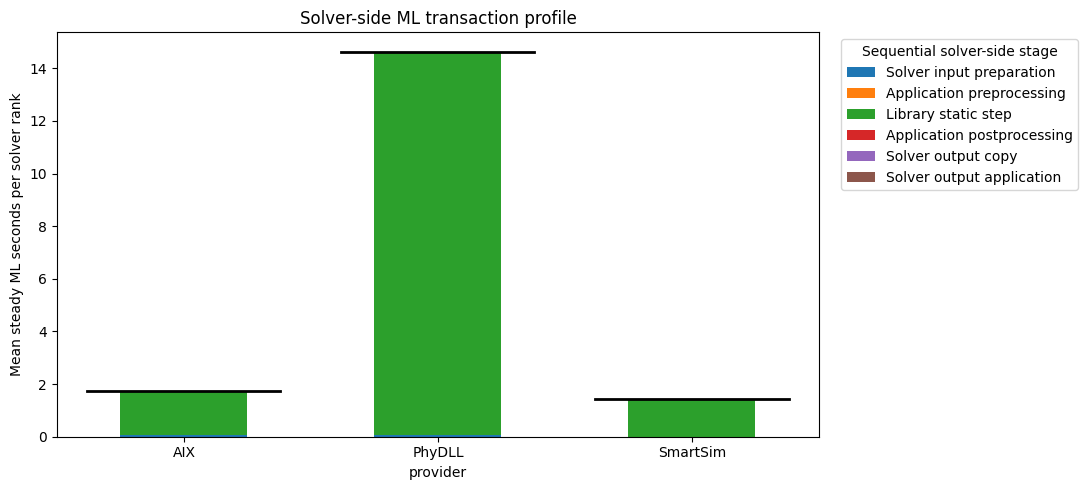

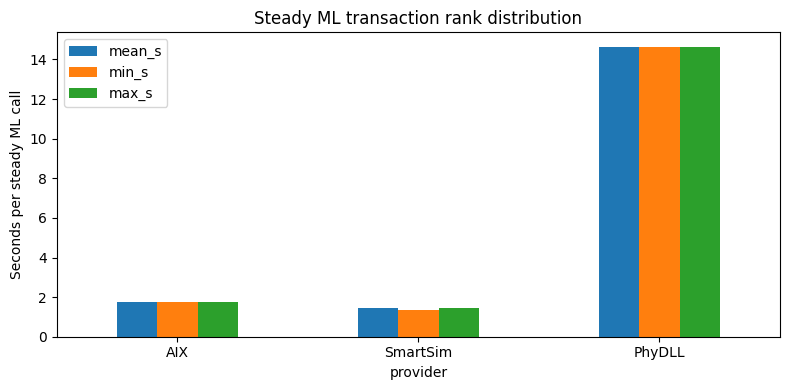

,mean_s,min_s,max_s
provider,,,
AIX,1.752851,1.752155,1.753442
SmartSim,1.429674,1.365098,1.453552
PhyDLL,14.637968,14.637575,14.638275


In [6]:
stack_order = [
    'Solver input preparation', 'Application preprocessing', 'Library static step',
    'Application postprocessing', 'Solver output copy', 'Solver output application',
]
stack = transaction[transaction.stage.isin(stack_order)].pivot(index='provider', columns='stage', values='mean_s').reindex(columns=stack_order).fillna(0)
roots = transaction[transaction.stage.eq('ML transaction wall time')].set_index('provider').mean_s
ax = stack.plot(kind='bar', stacked=True, figsize=(11, 5), ylabel='Mean steady ML seconds per solver rank', title='Solver-side ML transaction profile')
for x, provider in enumerate(stack.index):
    ax.plot([x - 0.38, x + 0.38], [roots[provider], roots[provider]], color='black', linewidth=2)
ax.legend(title='Sequential solver-side stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({'mean_s': roots, 'min_s': transaction[transaction.stage.eq('ML transaction wall time')].set_index('provider').min_s, 'max_s': transaction[transaction.stage.eq('ML transaction wall time')].set_index('provider').max_s})
comparison.plot(kind='bar', figsize=(8, 4), ylabel='Seconds per steady ML call', title='Steady ML transaction rank distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
comparison.round(6)


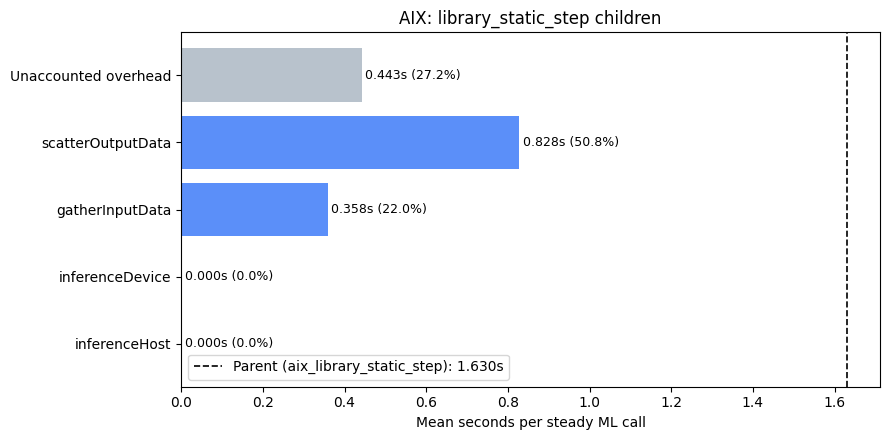

AIX: done


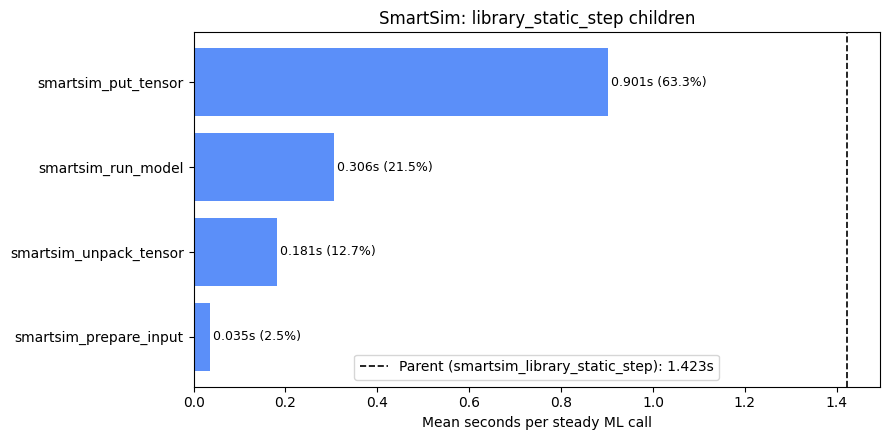

SmartSim: done


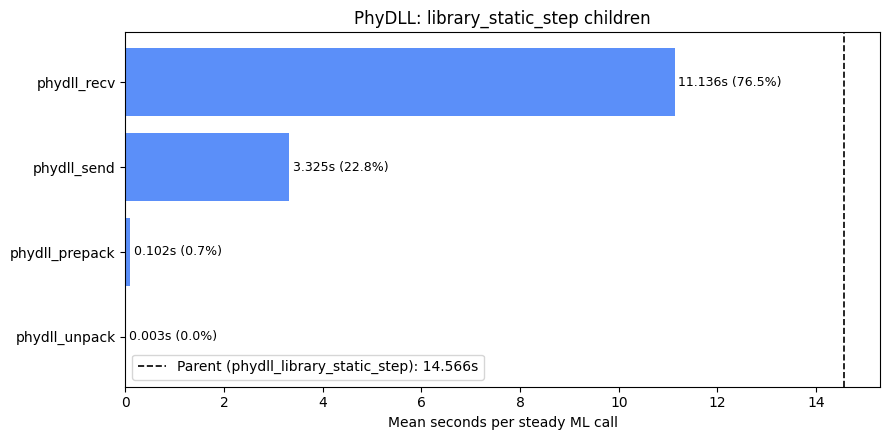

PhyDLL: done


In [7]:
# Horizontal bar charts: children of library_static_step, one per provider.
# Decomposes each provider's library static step wall-clock time per ML step.

CHILD_REGIONS = {
    'AIX': {
        'parent': 'aix_library_static_step',
        'children': [
            ('gatherInputData', True),
            ('inferenceDevice', True),
            ('inferenceHost', True),
            ('scatterOutputData', True),
        ],
    },
    'SmartSim': {
        'parent': 'smartsim_library_static_step',
        'children': [
            ('smartsim_prepare_input', False),
            ('smartsim_put_tensor', False),
            ('smartsim_run_model', False),
            ('smartsim_unpack_tensor', False),
        ],
    },
    'PhyDLL': {
        'parent': 'phydll_library_static_step',
        'children': [
            ('phydll_prepack', True),
            ('phydll_send', True),
            ('phydll_recv', True),
            ('phydll_unpack', True),
        ],
    },
}

def plot_child_bar(provider):
    parent_vals = per_rank_step_time(provider, CHILD_REGIONS[provider]['parent'])
    parent_mean = float(parent_vals.mean())

    child_data = []
    for child_name, is_cont in CHILD_REGIONS[provider]['children']:
        c_vals = per_rank_step_time(provider, child_name)
        child_data.append({
            'stage': child_name,
            'mean_s': c_vals.mean(),
            'min_s': c_vals.min(),
            'max_s': c_vals.max(),
        })
    child_data.sort(key=lambda d: d['mean_s'])
    child_df = pd.DataFrame(child_data)

    # Calculate residual (unaccounted time inside parent)
    measured_total = child_df['mean_s'].sum()
    residual = max(parent_mean - measured_total, 0.0)
    if residual > 0.001:
        residual_row = pd.DataFrame([{
            'stage': 'Unaccounted overhead',
            'mean_s': residual,
            'min_s': 0.0,
            'max_s': residual,
        }])
        child_df = pd.concat([child_df, residual_row], ignore_index=True)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors = ['#5b8ff9' if s != 'Unaccounted overhead' else '#b8c2cc' for s in child_df['stage']]
    bars = ax.barh(child_df['stage'], child_df['mean_s'], color=colors)

    # Annotate bars
    for bar, (_, row) in zip(bars, child_df.iterrows()):
        ax.text(bar.get_width() + (parent_mean * 0.005), bar.get_y() + bar.get_height()/2,
                f'{row["mean_s"]:.3f}s ({row["mean_s"]/parent_mean:.1%})',
                va='center', fontsize=9)

    ax.set_xlabel('Mean seconds per steady ML call')
    ax.axvline(x=parent_mean, color='black', linestyle='--', linewidth=1.2, label=f'Parent ({CHILD_REGIONS[provider]["parent"]}): {parent_mean:.3f}s')
    ax.set_title(f'{provider}: library_static_step children')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return child_df, parent_mean

bar_results = {}
for provider in ['AIX', 'SmartSim', 'PhyDLL']:
    bar_results[provider] = plot_child_bar(provider)
    print(f'{provider}: done')


## PhyDLL DL-client profile

The following is a dedicated service-rank view for the PhyDLL DL client (running on thread/rank 24). It is reported in a separate chart because the solver's blocking `phydll_library_static_step` overlaps these DL-client operations concurrently in wall time. A filtered MPI trace can connect both sides to derive the causal transaction critical path.

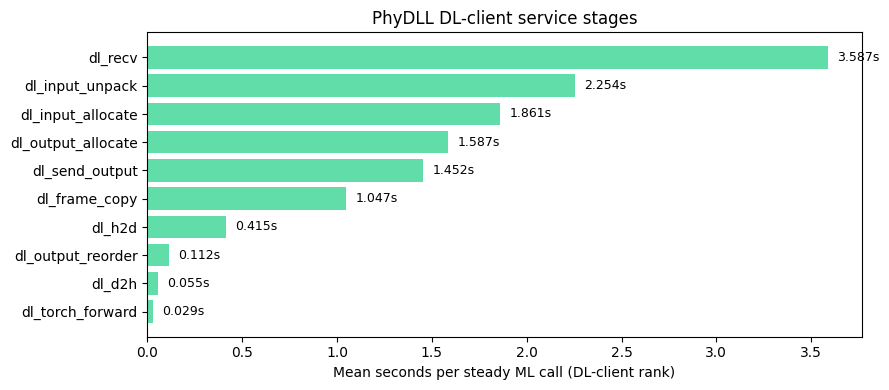

,stage,mean_s,min_s,max_s
6,dl_torch_forward,0.028521,0.028521,0.028521
7,dl_d2h,0.055482,0.055482,0.055482
8,dl_output_reorder,0.112011,0.112011,0.112011
5,dl_h2d,0.414850,0.414850,0.414850
1,dl_frame_copy,1.047145,1.047145,1.047145
9,dl_send_output,1.451838,1.451838,1.451838
2,dl_output_allocate,1.586648,1.586648,1.586648
3,dl_input_allocate,1.861030,1.861030,1.861030
4,dl_input_unpack,2.254005,2.254005,2.254005
0,dl_recv,3.586625,3.586625,3.586625


In [8]:
PHYDLL_SERVICE_REGIONS = [
    'dl_recv', 'dl_frame_copy', 'dl_output_allocate', 'dl_input_allocate',
    'dl_input_unpack', 'dl_h2d', 'dl_torch_forward',
    'dl_d2h', 'dl_output_reorder', 'dl_send_output'
]
phydll_frame = profiles['PhyDLL']
service = []
for region in PHYDLL_SERVICE_REGIONS:
    rows = latest_region(phydll_frame, region)
    rows = rows[rows.visits.gt(0)]
    if not rows.empty:
        # Single DL-client thread (thread 24); use its four-call mean.
        rows = rows[rows.thread_id.eq(SERVICE_RANK['PhyDLL'])]
        per_step = rows.time / rows.visits
        service.append({
            'stage': region,
            'mean_s': per_step.mean(),
            'min_s': per_step.min(),
            'max_s': per_step.max(),
        })
service_df = pd.DataFrame(service).sort_values('mean_s', ascending=True)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(service_df['stage'], service_df['mean_s'], color='#61dDAa')
for bar, (_, row) in zip(bars, service_df.iterrows()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{row["mean_s"]:.3f}s', va='center', fontsize=9)
ax.set_xlabel('Mean seconds per steady ML call (DL-client rank)')
ax.set_title('PhyDLL DL-client service stages')
plt.tight_layout()
plt.show()
service_df.round(6)


## AIx Collective Diagnostics & OTF2 Causal Verification

Combining the manual per-rank CSV timing (`AIX_DIAG_NATURAL_2524580` vs `AIX_DIAG_BARRIERS_2525508`) with OTF2 trace `2529874` establishes the following:

1. **Scatter Block Cause**: Solver workers enter `MPI_Scatterv` ~1.1–1.2 seconds before controller rank 24 reaches `MPI_Scatterv` because rank 24 is executing the centralized batching/inference loop (~747 PyTorch batches, ~0.44s CPU execution + H2D/D2H queues).
2. **Scatter Transmission**: The actual `MPI_Scatterv` payload transfer (142.4 MiB float) takes only **~10–40 ms** across all ranks.
3. **Barrier Behavior**: Inserting an explicit `MPI_Barrier` before `MPI_Scatterv` shifts the ~1.15s delay from `MPI_Scatterv` into `gather_scatter_barrier_s`, reducing `MPI_Scatterv` to ~2–4 ms while keeping total solver step time unchanged.
4. **CUDA Core Performance**: PyTorch CUDA-event timings on rank 24 show H2D ~88 ms, forward ~50 ms, and D2H ~50 ms across all 747 batches, confirming the model is fast and that **controller CPU dispatch/batch loop management** is the primary bottleneck idle-blocking all solver ranks.